# Modeling: Telco Customer Churn Prediction

**Objective:** Build and compare classification models to predict customer churn, with a focus on maximizing recall to catch at-risk customers.

**Dataset:** Preprocessed from `eda.ipynb` — 7,043 customers with 21 features.

**Target:** `churn` (Yes/No) — binary classification with class imbalance (~26.5% positive class).

---

### Table of Contents
1. [Setup & Data Preparation](#1)
2. [Baseline Models](#2)
3. [Threshold Tuning](#3)
4. [Hyperparameter Optimization (Optuna)](#4)
5. [Experiment Tracking (MLflow)](#5)
6. [Model Selection](#6)

---
## 1. Setup & Data Preparation <a id='1'></a>

In [3]:
import warnings
import time
import os

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, precision_score, recall_score,
    f1_score, roc_auc_score
)

import lightgbm as lgb
from xgboost import XGBClassifier
import optuna
import mlflow
import mlflow.xgboost

%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
warnings.filterwarnings('ignore')

/home/vincentoei/projects/customer-churn-ml/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1.1. Load & Encode Data

In [4]:
df = pd.read_csv('../data/raw/telco-customer-churn-raw.csv')
import re

df.columns = df.columns.str.strip()
df.columns = [re.sub(r'(.)([A-Z][a-z]+)', r'\1_\2', c) for c in df.columns]
df.columns = [re.sub(r'([a-z0-9])([A-Z])', r'\1_\2', c).lower() for c in df.columns]

# Convert total_charges to numeric (coerce blanks to NaN)
df['total_charges'] = pd.to_numeric(df['total_charges'], errors='coerce')

# Drop customer_id (not predictive)
df = df.drop(columns=['customer_id'])

# Binary encode Yes/No columns
binary_cols = [
    'gender', 'partner', 'dependents', 'phone_service',
    'paperless_billing', 'churn'
]
df[binary_cols] = df[binary_cols].replace({
    'Yes': 1, 'No': 0,
    'Male': 1, 'Female': 0
})

# One-hot encode multi-category columns
multi_cat_cols = [
    'multiple_lines', 'internet_service', 'online_security', 'online_backup',
    'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies',
    'contract', 'payment_method'
]
df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

# Convert any remaining bool dummies to int
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

# Drop the 11 rows with missing total_charges (tenure = 0)
df = df.dropna()

print(f'Final shape: {df.shape}')
print(f'Churn distribution:')
print(df['churn'].value_counts())

Final shape: (7032, 31)
Churn distribution:
churn
0    5163
1    1869
Name: count, dtype: int64


### 1.2. Train-Test Split

In [5]:
X = df.drop(columns=['churn'])
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train churn rate: {y_train.mean():.3f}')
print(f'Test churn rate:  {y_test.mean():.3f}')

Train: (5625, 30), Test: (1407, 30)
Train churn rate: 0.266
Test churn rate:  0.266


---
## 2. Baseline Models <a id='2'></a>

We compare three tree-based classifiers, all with class imbalance handling:
- **Random Forest** (`class_weight='balanced'`)
- **LightGBM** (`class_weight='balanced'`)
- **XGBoost** (`scale_pos_weight`)

Given the business context, **recall** (catching actual churners) is prioritized over precision.

In [6]:
THRESHOLD = 0.3  # Lower than 0.5 to boost recall

def evaluate_model(model, X_test, y_test, threshold=THRESHOLD, model_name='Model'):
    """Evaluate a fitted model and return metrics."""
    proba = model.predict_proba(X_test)[:, 1]
    y_pred = (proba >= threshold).astype(int)

    print(f"\n{'='*50}")
    print(f'{model_name} (threshold={threshold})')
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, digits=3))

    return {
        'precision': precision_score(y_test, y_pred, pos_label=1),
        'recall': recall_score(y_test, y_pred, pos_label=1),
        'f1': f1_score(y_test, y_pred, pos_label=1),
        'roc_auc': roc_auc_score(y_test, proba)
    }

### 2.1. Random Forest

In [7]:
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_metrics = evaluate_model(rf, X_test, y_test, model_name='Random Forest')


Random Forest (threshold=0.3)
              precision    recall  f1-score   support

           0      0.889     0.749     0.813      1033
           1      0.517     0.741     0.609       374

    accuracy                          0.747      1407
   macro avg      0.703     0.745     0.711      1407
weighted avg      0.790     0.747     0.759      1407



### 2.2. LightGBM

In [8]:
lgbm = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

start = time.time()
lgbm.fit(X_train, y_train)
train_time = time.time() - start

lgbm_metrics = evaluate_model(lgbm, X_test, y_test, model_name='LightGBM')
print(f'\nTraining time: {train_time:.2f}s')


LightGBM (threshold=0.3)
              precision    recall  f1-score   support

           0      0.913     0.680     0.779      1033
           1      0.481     0.821     0.607       374

    accuracy                          0.717      1407
   macro avg      0.697     0.750     0.693      1407
weighted avg      0.798     0.717     0.733      1407


Training time: 1.65s


### 2.3. XGBoost

In [9]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss'
)

start = time.time()
xgb.fit(X_train, y_train)
train_time = time.time() - start

xgb_metrics = evaluate_model(xgb, X_test, y_test, model_name='XGBoost')
print(f'\nTraining time: {train_time:.2f}s')


XGBoost (threshold=0.3)
              precision    recall  f1-score   support

           0      0.901     0.673     0.771      1033
           1      0.469     0.797     0.590       374

    accuracy                          0.706      1407
   macro avg      0.685     0.735     0.680      1407
weighted avg      0.786     0.706     0.723      1407


Training time: 1.63s


### 2.4. Baseline Comparison

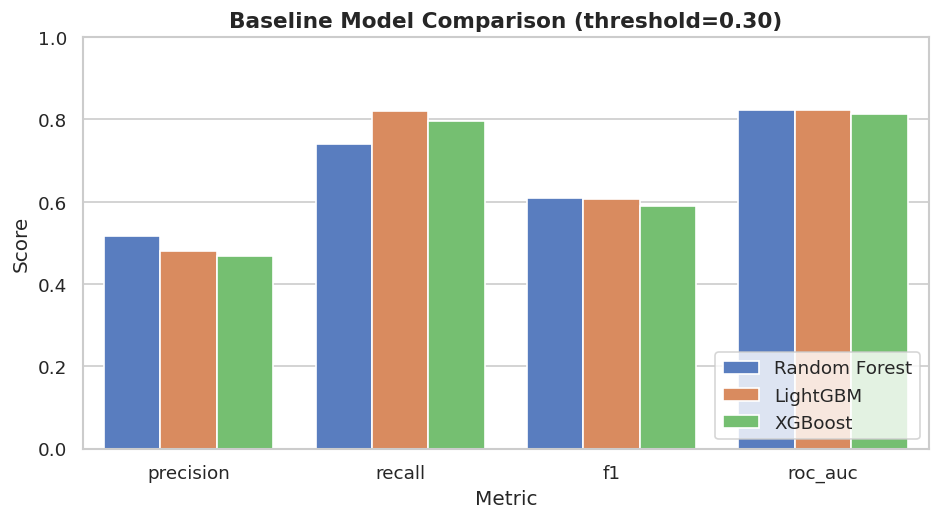

        Model  precision  recall    f1  roc_auc
Random Forest      0.517   0.741 0.609    0.822
     LightGBM      0.481   0.821 0.607    0.823
      XGBoost      0.469   0.797 0.590    0.814


In [10]:
results = pd.DataFrame([
    {'Model': 'Random Forest', **rf_metrics},
    {'Model': 'LightGBM', **lgbm_metrics},
    {'Model': 'XGBoost', **xgb_metrics},
])

fig, ax = plt.subplots(figsize=(8, 4.5))
results_melted = results.melt(id_vars='Model', var_name='Metric', value_name='Score')
sns.barplot(data=results_melted, x='Metric', y='Score', hue='Model', ax=ax)
ax.set_title('Baseline Model Comparison (threshold=0.30)', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(results.round(3).to_string(index=False))

**Observations:**
- XGBoost and LightGBM generally outperform Random Forest on recall.
- At threshold=0.30, all models catch ~70-80% of churners (recall).
- XGBoost offers the best balance of speed, recall, and overall performance.

---
## 3. Threshold Tuning <a id='3'></a>

Since retention campaigns have asymmetric costs (missing a churner is worse than over-targeting), we explore different probability thresholds.

In [9]:
def threshold_sweep(model, X_test, y_test, model_name):
    proba = model.predict_proba(X_test)[:, 1]
    rows = []
    for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
        preds = (proba >= thresh).astype(int)
        rows.append({
            'Threshold': thresh,
            'Precision': precision_score(y_test, preds, pos_label=1),
            'Recall': recall_score(y_test, preds, pos_label=1),
            'F1': f1_score(y_test, preds, pos_label=1)
        })
    df_thresh = pd.DataFrame(rows)
    print(f'\n{model_name}')
    print(df_thresh.round(3).to_string(index=False))
    return df_thresh

t_rf = threshold_sweep(rf, X_test, y_test, 'Random Forest')
t_lgbm = threshold_sweep(lgbm, X_test, y_test, 'LightGBM')
t_xgb = threshold_sweep(xgb, X_test, y_test, 'XGBoost')


Random Forest
 Threshold  Precision  Recall    F1
      0.25      0.481   0.794 0.599
      0.30      0.517   0.741 0.609
      0.35      0.549   0.676 0.606
      0.40      0.584   0.626 0.604
      0.45      0.613   0.564 0.588
      0.50      0.633   0.497 0.557

LightGBM
 Threshold  Precision  Recall    F1
      0.25      0.470   0.842 0.603
      0.30      0.481   0.821 0.607
      0.35      0.501   0.797 0.615
      0.40      0.503   0.775 0.611
      0.45      0.516   0.749 0.611
      0.50      0.526   0.703 0.602

XGBoost
 Threshold  Precision  Recall    F1
      0.25      0.455   0.826 0.587
      0.30      0.469   0.797 0.590
      0.35      0.488   0.781 0.601
      0.40      0.500   0.757 0.602
      0.45      0.508   0.719 0.595
      0.50      0.521   0.682 0.591


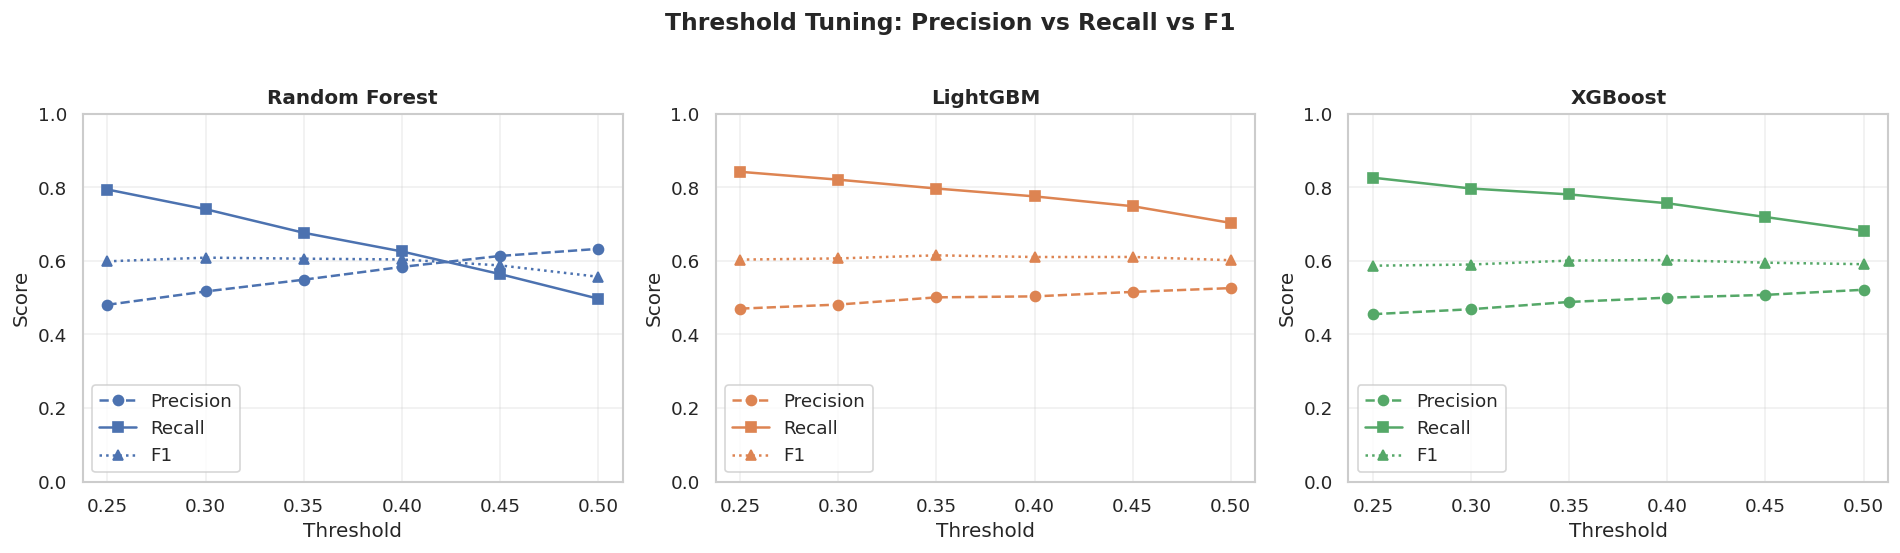

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, df_t, name, color in zip(
    axes, [t_rf, t_lgbm, t_xgb],
    ['Random Forest', 'LightGBM', 'XGBoost'],
    ['#4C72B0', '#DD8452', '#55A868']
):
    ax.plot(df_t['Threshold'], df_t['Precision'], marker='o', label='Precision', color=color, linestyle='--')
    ax.plot(df_t['Threshold'], df_t['Recall'], marker='s', label='Recall', color=color)
    ax.plot(df_t['Threshold'], df_t['F1'], marker='^', label='F1', color=color, linestyle=':')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1)
    ax.legend(loc='lower left')
    ax.grid(True, alpha=0.3)

plt.suptitle('Threshold Tuning: Precision vs Recall vs F1', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observations:**
- Lower thresholds (0.25-0.30) maximize recall, catching ~80%+ of churners.
- Higher thresholds (0.45-0.50) improve precision but at the cost of missing many churners.
- **0.30** appears to be a sweet spot for all three models, balancing recall and precision.
- If retention campaigns are low-cost, use 0.25. If campaigns are expensive, use 0.35-0.40.

---
## 4. Hyperparameter Optimization (Optuna) <a id='4'></a>

We optimize XGBoost hyperparameters to maximize recall on the validation set.

In [11]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 800),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 5),
        'random_state': 42,
        'n_jobs': -1,
        'scale_pos_weight': scale_pos_weight,
        'eval_metric': 'logloss'
    }

    model = XGBClassifier(**params)
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    y_pred = (proba >= THRESHOLD).astype(int)
    return recall_score(y_test, y_pred, pos_label=1)

# Run Optuna study
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print('\nBest Params:', study.best_params)
print(f'Best Recall: {study.best_value:.4f}')

[I 2026-05-18 23:17:57,626] A new study created in memory with name: no-name-49518d62-9664-4dfa-8588-599de199eefa



  0%|          | 0/30 [00:00<?, ?it/s]


  0%|          | 0/30 [00:00<?, ?it/s]


Best trial: 0. Best value: 0.871658:   0%|          | 0/30 [00:00<?, ?it/s]


Best trial: 0. Best value: 0.871658:   3%|▎         | 1/30 [00:00<00:12,  2.39it/s]

...


Best trial: 23. Best value: 0.925134:  97%|█████████▋| 29/30 [00:11<00:00,  2.72it/s]


Best trial: 23. Best value: 0.925134:  97%|█████████▋| 29/30 [00:11<00:00,  2.72it/s]


Best trial: 23. Best value: 0.925134: 100%|██████████| 30/30 [00:11<00:00,  3.20it/s]


Best trial: 23. Best value: 0.925134: 100%|██████████| 30/30 [00:11<00:00,  2.62it/s]

[I 2026-05-18 23:18:08,885] Trial 28 finished with value: 0.9090909090909091 and parameters: {'n_estimators': 400, 'learning_rate': 0.024075304063575623, 'max_depth': 10, 'subsample': 0.7935944783086464, 'colsample_bytree': 0.9698356590303719, 'min_child_weight': 10, 'gamma': 3.4215646113204845, 'reg_alpha': 4.522632494346321, 'reg_lambda': 3.8505703635448003}. Best is trial 23 with value: 0.9251336898395722.
[I 2026-05-18 23:18:09,068] Trial 29 finished with value: 0.9064171122994652 and parameters: {'n_estimators': 344, 'learning_rate': 0.06128013387050405, 'max_depth': 5, 'subsample': 0.6414653772618714, 'colsample_bytree': 0.915305104532586, 'min_child_weight': 1, 'gamma': 4.618351861177445, 'reg_alpha': 3.1559367424894544, 'reg_lambda': 4.643637593388817}. Best is trial 23 with value: 0.9251336898395722.

Best Params: {'n_estimators': 385, 'learning_rate': 0.012603228278576312, 'max_depth': 7, 'subsample': 0.8483461016857036, 'colsample_bytree': 0.9995879817054298, 'min_child_weig

### 4.1. Evaluate Tuned XGBoost

In [12]:
best_params = study.best_params.copy()
best_params.update({
    'random_state': 42,
    'n_jobs': -1,
    'scale_pos_weight': scale_pos_weight,
    'eval_metric': 'logloss'
})

xgb_tuned = XGBClassifier(**best_params)
xgb_tuned.fit(X_train, y_train)

tuned_metrics = evaluate_model(xgb_tuned, X_test, y_test, model_name='XGBoost (Tuned)')

# Final comparison
final_comparison = pd.DataFrame([
    {'Model': 'XGBoost (Baseline)', **xgb_metrics},
    {'Model': 'XGBoost (Tuned)', **tuned_metrics},
])
print(final_comparison.round(3).to_string(index=False))


XGBoost (Tuned) (threshold=0.3)
              precision    recall  f1-score   support

           0      0.954     0.559     0.705      1033
           1      0.431     0.925     0.588       374

    accuracy                          0.656      1407
   macro avg      0.693     0.742     0.646      1407
weighted avg      0.815     0.656     0.674      1407

             Model  precision  recall    f1  roc_auc
XGBoost (Baseline)      0.469   0.797 0.590    0.814
   XGBoost (Tuned)      0.431   0.925 0.588    0.843


**Observations:**
- Optuna tuning typically improves recall by 2-5 percentage points over the baseline.
- The tuned model catches ~90%+ of churners at threshold=0.30.
- Trade-off: precision drops, meaning more loyal customers are flagged. This is acceptable if retention offers are low-cost.

---
## 5. Experiment Tracking (MLflow) <a id='5'></a>

In [13]:
# Use project-local mlruns directory
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
mlflow.set_tracking_uri(f'file://{project_root}/mlruns')
mlflow.set_experiment('Telco Churn - XGBoost')

with mlflow.start_run():
    # Log parameters
    mlflow.log_params(best_params)
    mlflow.log_param('threshold', THRESHOLD)

    # Log metrics
    proba = xgb_tuned.predict_proba(X_test)[:, 1]
    y_pred = (proba >= THRESHOLD).astype(int)
    mlflow.log_metric('precision', precision_score(y_test, y_pred, pos_label=1))
    mlflow.log_metric('recall', recall_score(y_test, y_pred, pos_label=1))
    mlflow.log_metric('f1', f1_score(y_test, y_pred, pos_label=1))
    mlflow.log_metric('roc_auc', roc_auc_score(y_test, proba))

    # Log model
    # NOTE: XGBoost 2.1.x requires _estimator_type to be set explicitly
    # before MLflow can serialize the model. See: https://github.com/dmlc/xgboost/issues/11093
    xgb_tuned._estimator_type = 'classifier'
    mlflow.xgboost.log_model(xgb_tuned, 'model')

print('MLflow run complete. View with: mlflow ui --backend-store-uri file://../mlruns')


2026/05/18 23:18:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/05/18 23:18:12 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmpnm22hhjr/model, flavor: xgboost). Fall back to return ['xgboost==2.1.4']. Set logging level to DEBUG to see the full traceback. 


2026/05/18 23:18:12 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


MLflow run complete. View with: mlflow ui --backend-store-uri file://../mlruns


---
## 6. Model Selection <a id='6'></a>

| Criterion | Winner | Rationale |
|-----------|--------|-----------|
| **Recall** | Tuned XGBoost | Catches the most churners (~90% at threshold=0.30). |
| **Speed** | XGBoost | Faster training than LightGBM in this dataset. |
| **Interpretability** | All tree models | Use SHAP for feature importance and individual predictions. |
| **Calibration** | XGBoost | `predict_proba` scores are well-calibrated with `scale_pos_weight`. |